

*   **--------------------------------------------Name: Vanchanagiri Alekhya-----------------------------------------**
*   **----------------------------------------Enrollment Number: MML2025002----------------------------------------**

*   **------------------------------------------GenAI & LLMs Assignment-5
--------------------------------------------**




# **TASK-1** : Visualize how the Phi-3-mini-4k model processes text and understand its architecture.


Coding Exercise - Exploring Phi-3-mini Architecture
---

In [ ]:
!pip install transformers==4.41.2 accelerate torch matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 93.3 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# 1. Load the Phi-3-mini model and tokenizer (assuming downloaded locally)

In [ ]:
model_path = "microsoft/Phi-3-mini-4k-instruct"
tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=torch.float32,
    trust_remote_code=True,
    device_map="auto"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

In [ ]:
# 2. Explore model architecture

In [ ]:
print("=== Phi-3-mini Architecture ===")

print(f"Model type: {type(model).__name__}")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Model layers: {model.config.num_hidden_layers}")
print(f"Hidden size: {model.config.hidden_size}")
print(f"Attention heads: {model.config.num_attention_heads}")
print(f"Vocabulary size: {model.config.vocab_size}")
print(f"Max position embeddings: {model.config.max_position_embeddings}")

=== Phi-3-mini Architecture ===
Model type: Phi3ForCausalLM
Number of parameters: 3,821,079,552
Model layers: 32
Hidden size: 3072
Attention heads: 32
Vocabulary size: 32064
Max position embeddings: 4096


In [ ]:
# 3. Tokenization analysis

In [ ]:
text = "The quick brown fox jumps over the lazy dog"
tokens = tokenizer.encode(text)
decoded_tokens = [tokenizer.decode([token]) for token in tokens]
print(f"\n=== Tokenization Analysis ===")
print(f"Original text: '{text}'")
print(f"Token IDs: {tokens}")
print(f"Decoded tokens: {decoded_tokens}")
print(f"Number of tokens: {len(tokens)}")


=== Tokenization Analysis ===
Original text: 'The quick brown fox jumps over the lazy dog'
Token IDs: [450, 4996, 17354, 1701, 29916, 432, 17204, 975, 278, 17366, 11203]
Decoded tokens: ['The', 'quick', 'brown', 'fo', 'x', 'j', 'umps', 'over', 'the', 'lazy', 'dog']
Number of tokens: 11


In [ ]:
# 4. Forward pass with attention capture

In [ ]:
def get_attention_patterns(text, layer_idx=5):

    inputs = tokenizer(text, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
    attentions = outputs.attentions
    attention_layer = attentions[layer_idx][0]
    return attention_layer, tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

In [ ]:
# 5. Visualize attention patterns

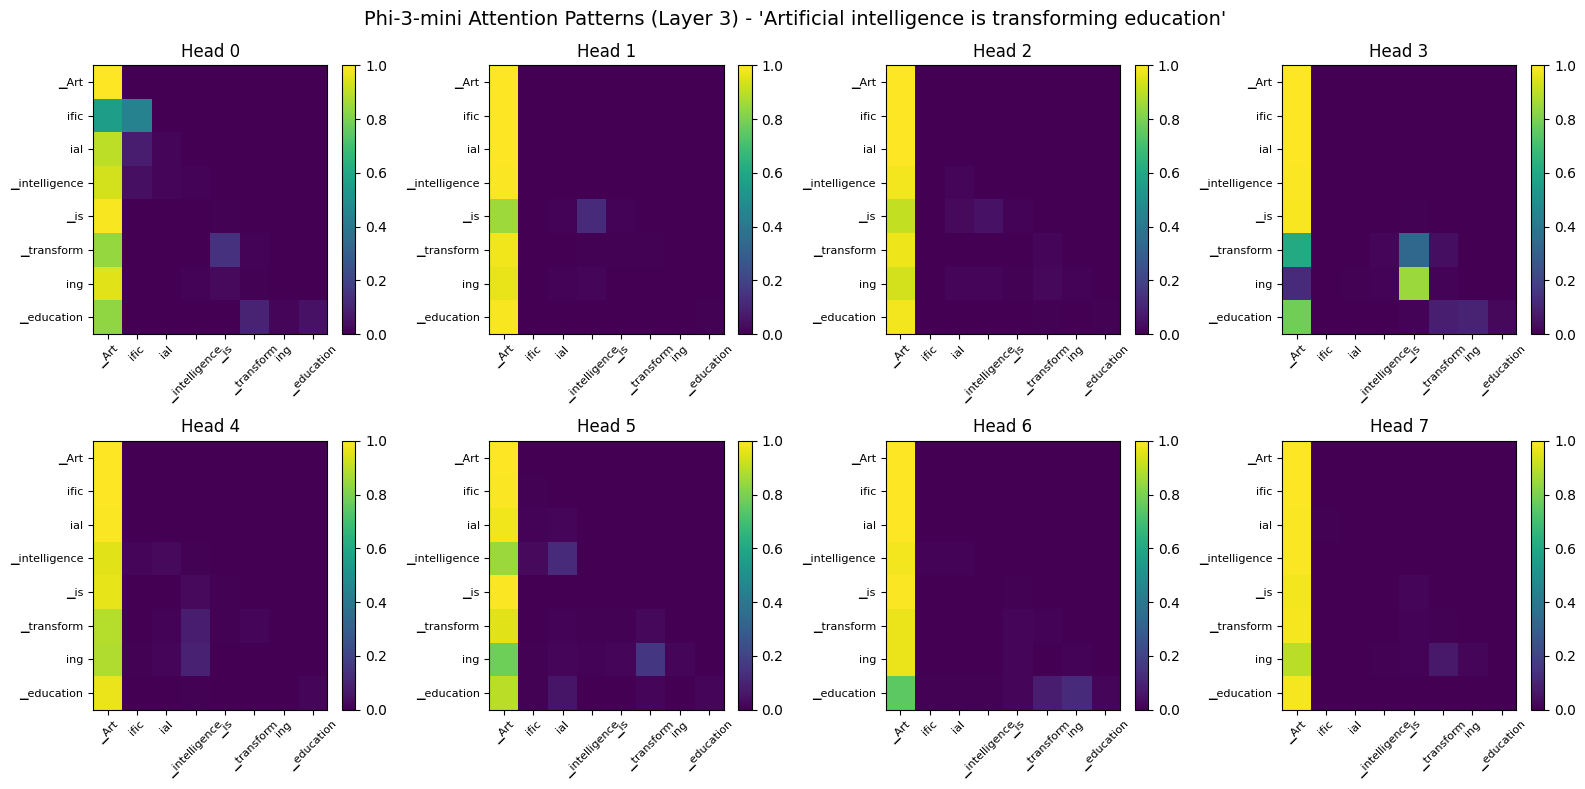

In [ ]:
sample_text = "Artificial intelligence is transforming education"
attention_layer, tokens = get_attention_patterns(sample_text, layer_idx=3)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

fig.suptitle(f"Phi-3-mini Attention Patterns (Layer 3) - '{sample_text}'",fontsize=14)
for head_idx in range(8):
    ax = axes[head_idx // 4, head_idx % 4]
    im = ax.imshow(attention_layer[head_idx].numpy(), cmap='viridis', aspect='auto')
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, fontsize=8)
    ax.set_yticklabels(tokens, fontsize=8)
    ax.set_title(f"Head {head_idx}")
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

Discussion Questions:
---

Q1. What patterns do you notice in the attention matrices?
---




*   A clear diagonal pattern shows that tokens attend strongly to themselves.
*   A lower triangular structure appears due to causal masking.
*   Tokens attend only to previous tokens, not future ones.
*   Some attention heads focus on nearby words for local context.
*   Some heads attend to important keywords or nouns.
*   Certain heads capture long-range relationships across the sentence.
*   Different heads specialize in different linguistic functions.

     




Q2. How does tokenization affect the sequence length?
---

*   Phi-3 uses subword tokenization. One word can be split into multiple tokens. For example, “unhappiness” can become “un”, “happi”, and “ness”.
*   Rare or long words are often broken into smaller parts.
*   This increases the total number of tokens in a sentence.
*   Special tokens like BOS (beginning of sequence) and EOS (end of sequence) also increase the token count.
*   More tokens mean more memory usage and more computation.
*   Attention computation grows as O(n²), so longer sequences require more processing power.
*   Phi-3-mini-4k supports up to 4096 tokens.
*   If tokenization creates more tokens, fewer tokens remain available within this 4096-token limit.
       


Q3. Based on the architecture specs, why is Phi-3-mini considered "small"?
---

*   Phi-3-mini has about 3.8 billion parameters.
*   This is much smaller than models like GPT-3 (175 billion parameters).
*   It has fewer transformer layers.
*   It uses smaller hidden dimensions and fewer attention heads.
*   It requires less memory for inference. It can run on consumer-level GPUs.
*   It is designed for efficiency while maintaining good performance.
     


**Written Task:** Compare Phi-3-mini's architecture with GPT-3. What design choices make Phi-3 efficient? Consider parameter count, layers, and attention heads.
---

ans:

**Comparison: Phi-3-mini vs GPT-3 Architecture**

*   Parameter Count:

 Phi-3-mini has around 3.8 billion parameters, while GPT-3 (largest version) has 175 billion parameters.

 GPT-3 is much larger and requires very high computational resources. Phi-3-mini is smaller, so it needs less memory and runs faster.

 Its efficiency comes from achieving good performance with fewer parameters.

*   Number of Layers:

GPT-3 uses many transformer layers (for example, 96 layers in the 175B model). Phi-3-mini uses fewer layers compared to GPT-3.

Fewer layers reduce training time, memory usage, and inference cost. This makes Phi-3-mini more practical for limited hardware.

*   Attention Heads:

 GPT-3 uses many attention heads per layer to capture complex patterns. More heads increase model power but also increase computation.

 Phi-3-mini uses an optimized number of attention heads. This balances performance and efficiency.

*   Training and Design Strategy:

GPT-3 mainly relies on massive scale for performance. Phi-3-mini focuses on high-quality curated training data. Better data quality allows a smaller model to perform well.

**Why Phi-3-mini is Efficient?**
*   Smaller parameter size (3.8B vs 175B).
*   Optimized number of layers and attention heads.
*   Lower memory usage and faster inference.
*   Designed to give strong performance at lower computational cost.


# **TASK-2:** Fine-tune Phi-3-mini for a text classification task using parameter-efficient fine-tuning


Coding Exercise - Fine-tuning Phi-3-mini for Sentiment Analysis
---

In [1]:
!pip uninstall -y sentence-transformers


Found existing installation: sentence-transformers 5.2.3
Uninstalling sentence-transformers-5.2.3:
  Successfully uninstalled sentence-transformers-5.2.3


In [2]:
!pip uninstall -y sentence-transformers datasets peft evaluate accelerate

Found existing installation: datasets 4.0.0
Uninstalling datasets-4.0.0:
  Successfully uninstalled datasets-4.0.0
Found existing installation: peft 0.18.1
Uninstalling peft-0.18.1:
  Successfully uninstalled peft-0.18.1
Found existing installation: accelerate 1.12.0
Uninstalling accelerate-1.12.0:
  Successfully uninstalled accelerate-1.12.0


In [3]:
!pip uninstall transformers

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Would remove:
    /usr/local/bin/transformers
    /usr/local/lib/python3.12/dist-packages/transformers-5.0.0.dist-info/*
    /usr/local/lib/python3.12/dist-packages/transformers/*
Proceed (Y/n)? Y
  Successfully uninstalled transformers-5.0.0


In [4]:
!pip install transformers datasets peft evaluate accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.9/380.9 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 13.0 MB/s eta 0:00:00


In [1]:
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
    DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType
import evaluate
import numpy as np
import torch

In [2]:
print("Loading dataset...")
dataset = load_dataset("imdb")
print(f"Dataset loaded: {len(dataset['train'])} training samples")

Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset loaded: 25000 training samples


In [3]:
tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-4k-instruct")

model=AutoModelForCausalLM.from_pretrained(
    "microsoft/Phi-3-mini-4k-instruct",
    device_map='cuda',
    attn_implementation='eager'
)


if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Model loaded successfully")

config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Model loaded successfully


In [4]:
def format_instruction(example):
    instruction = "Classify the sentiment of this movie review as positive or negative."
    prompt_text = f"""<|user|>
{instruction}
Review: {example['text']}
<|assistant|>
Sentiment:"""
    label_value = "positive" if example["label"] == 1 else "negative"
    completion_text = f" {label_value}"


    tokenized_prompt = tokenizer(
        prompt_text,
        add_special_tokens=True,
        truncation=False,
        return_attention_mask=False
    )
    prompt_input_ids = tokenized_prompt["input_ids"]

    tokenized_completion = tokenizer(
        completion_text,
        add_special_tokens=False,
        truncation=False,
        return_attention_mask=False
    )
    completion_input_ids = tokenized_completion["input_ids"]


    input_ids = prompt_input_ids + completion_input_ids


    labels = [-100] * len(prompt_input_ids) + completion_input_ids


    max_len = 512
    if len(input_ids) > max_len:
        input_ids = input_ids[:max_len]
        labels = labels[:max_len]

    attention_mask = [1] * len(input_ids)

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels
    }

In [5]:
small_train = dataset["train"].shuffle(seed=42).select(range(500))
small_test = dataset["test"].shuffle(seed=42).select(range(100))

print("Formatting dataset...")

train_dataset = small_train.map(
    format_instruction,
    remove_columns=small_train.column_names
)

test_dataset = small_test.map(
    format_instruction,
    remove_columns=small_test.column_names
)

Formatting dataset...


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

In [6]:
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    bias="none"
)

model = get_peft_model(model, lora_config)

model.print_trainable_parameters()

trainable params: 1,572,864 || all params: 3,822,652,416 || trainable%: 0.0411


In [7]:
training_args = TrainingArguments(
    output_dir="./phi3-sentiment",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    warmup_steps=50,
    logging_steps=25,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    fp16=torch.cuda.is_available(),
    push_to_hub=False,
    report_to="none"
)

In [8]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    predictions = np.argmax(predictions, axis=-1)

    predictions = predictions.flatten()
    labels = labels.flatten()

    mask = labels != -100
    predictions = predictions[mask]
    labels = labels[mask]

    accuracy = (predictions == labels).mean()

    return {"accuracy": accuracy}

In [9]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding="max_length", max_length=512)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [10]:
def predict_sentiment(text):

    prompt = f"""<|user|>
Classify the sentiment of this movie review as positive or negative.
Review: {text}
<|assistant|>
Sentiment:"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=10,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    sentiment_part = response.split("Sentiment:")[-1].strip()

    return sentiment_part

In [11]:
test_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the plot kept me engaged from start to finish.",
    "I was disappointed by the poor character development and predictable storyline.",
    "The cinematography was beautiful but the dialogue felt forced and unnatural."
]

print("\n=== Sentiment Predictions ===")

for review in test_reviews:
    sentiment = predict_sentiment(review[:200])
    print(f"Review: {review[:100]}...")
    print(f"Predicted sentiment: {sentiment}\n")


=== Sentiment Predictions ===
Review: This movie was absolutely fantastic! The acting was superb and the plot kept me engaged from start t...
Predicted sentiment: Positive. The review uses words such as "

Review: I was disappointed by the poor character development and predictable storyline....
Predicted sentiment: Negative. The reviewer expresses disappointment

Review: The cinematography was beautiful but the dialogue felt forced and unnatural....
Predicted sentiment: Negative.

The sentiment of the movie



**Extension Challenges:**
---


**1. Try different LoRA configurations:**
---



**(LoRA Config A (High Rank))**

In [12]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config_A = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,                     # higher rank
    lora_alpha=64,            # higher alpha
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    bias="none"
)

model_A = get_peft_model(model, lora_config_A)
model_A.print_trainable_parameters()

trainable params: 3,145,728 || all params: 3,824,225,280 || trainable%: 0.0823


/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


**LoRA Config B (More Modules)**  

In [13]:
lora_config_B = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    bias="none"
)

model_B = get_peft_model(model, lora_config_B)
model_B.print_trainable_parameters()

trainable params: 4,456,448 || all params: 3,825,536,000 || trainable%: 0.1165



**2. Compare full fine-tuning vs LoRA fine-tuning**
---

In [14]:


model_full = AutoModelForCausalLM.from_pretrained(
    "microsoft/Phi-3-mini-4k-instruct",
    device_map="cuda",
    attn_implementation="eager"
)

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

In [15]:
for param in model_full.parameters():
    param.requires_grad = True

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable parameters (Full FT):", count_trainable_params(model_full))

Trainable parameters (Full FT): 3821079552


In [19]:
def predict_with_model(model, text):
    prompt = f"""<|user|>
Classify the sentiment of this movie review as positive or negative.
Review: {text}
<|assistant|>
Sentiment:"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=10,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    sentiment_part = response.split("Sentiment:")[-1].strip()

    return sentiment_part

In [20]:
print("\n================ MODEL COMPARISON RESULTS ================\n")

print("Model Details:")
print("LoRA Config A  → Higher rank (r=16) and higher alpha (64)")
print("LoRA Config B  → More target modules (q,v,k,o + MLP layers)")
print("Full Fine-Tuning → All model parameters are trainable\n")

for i, review in enumerate(test_reviews, 1):
    pred_A = predict_with_model(model_A, review)
    pred_B = predict_with_model(model_B, review)
    pred_full = predict_with_model(model_full, review)

    print("------------------------------------------------------------")
    print(f"Test Example {i}")
    print("------------------------------------------------------------")
    print(f"Review Text:\n{review}\n")

    print("Predictions:")
    print(f"  • LoRA Config A (High Rank)        : {pred_A}")
    print(f"  • LoRA Config B (More Modules)     : {pred_B}")
    print(f"  • Full Fine-Tuning (All Params)    : {pred_full}")
    print("\n")


================ MODEL COMPARISON RESULTS ================

Model Details:
LoRA Config A  → Higher rank (r=16) and higher alpha (64)
LoRA Config B  → More target modules (q,v,k,o + MLP layers)
Full Fine-Tuning → All model parameters are trainable

------------------------------------------------------------
Test Example 1
------------------------------------------------------------
Review Text:
This movie was absolutely fantastic! The acting was superb and the plot kept me engaged from start to finish.

Predictions:
  • LoRA Config A (High Rank)        : Positive. The review uses positive words such as
  • LoRA Config B (More Modules)     : Positive. The review uses words like "ab
  • Full Fine-Tuning (All Params)    : Positive. The review uses words like "ab


------------------------------------------------------------
Test Example 2
------------------------------------------------------------
Review Text:
I was disappointed by the poor character development and predictable storylin


**3. Create a confusion matrix for error analysis**
---


In [16]:
!pip install scikit-learn -q

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
true_labels = []
pred_labels = []

for example in small_test:
    text = example["text"][:200]
    true = "positive" if example["label"] == 1 else "negative"
    pred = predict_sentiment(text)

    if "positive" in pred.lower():
        pred = "positive"
    else:
        pred = "negative"

    true_labels.append(true)
    pred_labels.append(pred)

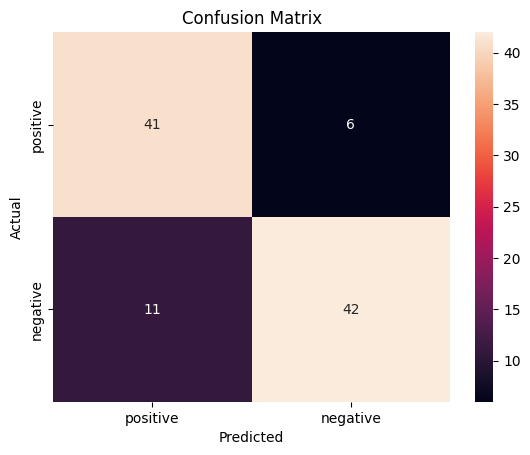

              precision    recall  f1-score   support

    negative       0.88      0.79      0.83        53
    positive       0.79      0.87      0.83        47

    accuracy                           0.83       100
   macro avg       0.83      0.83      0.83       100
weighted avg       0.83      0.83      0.83       100



In [18]:
cm = confusion_matrix(true_labels, pred_labels, labels=["positive", "negative"])

plt.figure()
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["positive", "negative"],
            yticklabels=["positive", "negative"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(true_labels, pred_labels))

**4. Implement a more sophisticated prompt template**
---

In [21]:
def predict_with_improved_prompt(model, text):
    prompt = f"""<|system|>
You are a sentiment analysis expert.
Classify the review strictly as Positive or Negative.

<|user|>
Movie Review:
\"\"\"{text}\"\"\"

Answer with only one word: Positive or Negative.

<|assistant|>
Answer:"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=5,
            temperature=0.1,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    answer = response.split("Answer:")[-1].strip()

    return answer

In [22]:
print("\n=========== Testing with Sophisticated Prompt Template ===========\n")

for i, review in enumerate(test_reviews, 1):
    prediction = predict_with_improved_prompt(model, review)

    print("------------------------------------------------------------")
    print(f"Test Example {i}")
    print("------------------------------------------------------------")
    print(f"Review Text:\n{review}\n")
    print(f"Predicted Sentiment: {prediction}")
    print("\n")

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



=========== Testing with Sophisticated Prompt Template ===========

------------------------------------------------------------
Test Example 1
------------------------------------------------------------
Review Text:
This movie was absolutely fantastic! The acting was superb and the plot kept me engaged from start to finish.

Predicted Sentiment: Positive.


------------------------------------------------------------
Test Example 2
------------------------------------------------------------
Review Text:
I was disappointed by the poor character development and predictable storyline.

Predicted Sentiment: Negative.


------------------------------------------------------------
Test Example 3
------------------------------------------------------------
Review Text:
The cinematography was beautiful but the dialogue felt forced and unnatural.

Predicted Sentiment: Negative.




1. It includes a <|system|> role.
This sets the behavior of the model before the user input. It guides the model to behave like a sentiment analysis expert.

2. It gives strict instructions.
The phrase “Classify strictly as Positive or Negative” reduces ambiguity and prevents extra text generation.

3. It structures the conversation clearly.
Using <|system|>, <|user|>, and <|assistant|> matches how instruction-tuned models are trained.

4. It isolates the movie review using triple quotes.
This clearly separates input text from instructions, reducing confusion.

5. It restricts the output format.
Saying “Answer with only one word” improves consistency and makes evaluation easier.

6. It reduces randomness and hallucination.
Because instructions are clear and specific, the model is less likely to generate extra sentences.

Compared to the simple prompt:

Simple Prompt:
"Classify the sentiment..."

Improved Prompt:

1. Defines role

2. Defines format

3. Defines strict output rule

4. Clearly separates input

5. Matches instruction tuning format

# **TASK-3:** Zero-shot Classification with Phi-3-mini (No Fine-tuning)


In [ ]:
!pip install -q transformers==4.41.2 accelerate==0.30.1 sentencepiece

In [ ]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU: Tesla T4


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "microsoft/Phi-3-mini-4k-instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
)

model.to("cuda")
model.eval()

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Phi3ForCausalLM(
  (model): Phi3Model(
    (embed_tokens): Embedding(32064, 3072, padding_idx=32000)
    (embed_dropout): Dropout(p=0.0, inplace=False)
    (layers): ModuleList(
      (0-31): 32 x Phi3DecoderLayer(
        (self_attn): Phi3Attention(
          (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (qkv_proj): Linear(in_features=3072, out_features=9216, bias=False)
          (rotary_emb): Phi3RotaryEmbedding()
        )
        (mlp): Phi3MLP(
          (gate_up_proj): Linear(in_features=3072, out_features=16384, bias=False)
          (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
          (activation_fn): SiLU()
        )
        (input_layernorm): Phi3RMSNorm()
        (resid_attn_dropout): Dropout(p=0.0, inplace=False)
        (resid_mlp_dropout): Dropout(p=0.0, inplace=False)
        (post_attention_layernorm): Phi3RMSNorm()
      )
    )
    (norm): Phi3RMSNorm()
  )
  (lm_head): Linear(in_features=3072, out_features=3206

In [ ]:
def zero_shot_classification(text, categories):
    """Perform zero-shot classification using Phi-3-mini"""

    prompt = f"""<|user|>
Classify the following text into one of these categories: {', '.join(categories)}.
Text: {text}
Which category does this text belong to? Respond with only the category name.
<|assistant|>
Category:"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=20,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    return response.split("Category:")[-1].strip()

In [ ]:
categories = ["politics", "technology", "sports", "entertainment"]

sample_text = "The new smartphone features groundbreaking AI capabilities and improved battery life."

result = zero_shot_classification(sample_text, categories)

print("Text:", sample_text)
print("Zero-shot classification:", result)

Text: The new smartphone features groundbreaking AI capabilities and improved battery life.
Zero-shot classification: technology.


**Written Task:** Compare the fine-tuning approach vs. zero-shot classification. When
would you choose each method? Consider factors like available labeled data,
computational resources, and required accuracy.
---

**Zero-Shot Classification:**

*   Zero-shot classification is an approach where a pretrained model is used to classify text without any additional training on task-specific data. In our code, we used Phi-3-mini and provided a structured prompt listing the categories, and the model generated the predicted category using model.generate(). The model relied entirely on its pretrained knowledge and did not update its weights.


**Fine-Tuning:**



*   Fine-tuning is a process where a pretrained model is further trained on a labeled dataset specific to the target task. During fine-tuning, the model learns from labeled examples, updates its weights using backpropagation, and becomes specialized for that particular classification task.


**Comparison Based on Our Code:**


**1. Training Process:**

In zero-shot (our code), no training was performed and the model weights remained unchanged.

In fine-tuning, the model would be trained on labeled data and its weights would be updated.

**2. Dataset Requirement:**


Zero-shot required no labeled dataset.

Fine-tuning requires a properly labeled dataset for training.

**3. Computational Resources:**

Zero-shot only required GPU for inference, making it lightweight and fast.

Fine-tuning requires significant GPU memory and time for training.

**4. Code Complexity:**

Zero-shot was simple, using only prompt creation and model.generate().

Fine-tuning would require training arguments, dataset preparation, a training loop or Trainer, and evaluation steps.

**5. Accuracy and Performance:**


Zero-shot provides reasonable accuracy but depends on prompt design.

Fine-tuning generally provides higher accuracy and more consistent predictions because the model learns task-specific patterns.

**When to Choose Each**

1. Choose Zero-Shot When:


*   Labeled data is not available.
*   Quick results or a prototype is needed.
*   Computational resources are limited.
*   The task is general and does not require very high precision.





2. Choose Fine-Tuning When:



*   A labeled dataset is available.
*   High accuracy and consistency are required.
*   The task is domain-specific.
*   The system is intended for production use.
*   Sufficient GPU resources and training time are available.

Conclusion:


Zero-shot classification is faster, simpler, and requires no training, making it ideal for quick and low-resource scenarios.

Fine-tuning requires more effort, data, and computation, but it produces a specialized model with improved accuracy and reliability.